# PyTorch Customer data

We've used some datasets with PyTorch before but how do you get your own data into PyTorch? One of the way to do is via: custom datasets.

## Domain Libraries

Depending on what you're working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data loading functions and customizable dataloading function

In [1]:
import torch
from torch import nn

# Note: PYTorch 1.10.0 + is required for this course
torch.__version__

'2.13.0+cu126'

In [2]:
# Setup device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device

'cuda'

In [4]:
!nvidia-smi

Thu Aug 20 13:37:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P5              7W /   35W |     913MiB /   4096MiB |     23%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Get data

Our dataset is a subset of the Food101 dataset (750 training, 250 testing)

Food101 starts 101 different classes of food. Our dataset starts with 3 classes of food and only 10% of the images. 

Why do this?

When starting out ML projects, it's important to try out on a small scale and then increase the scale when necesaary. The whole point is to speed up how fast you can experiment. 

In [5]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("datasets/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory already exists, skipping download.")
else:
    print(f"{image_path} directory does not exist, creating one...")
    image_path.mkdir(parents=True,
                     exist_ok = True)

# # Download pizza, steak and sushi data
# with open(image_path / "pizza_steak_sushi.zip", "wb") as f:
#     request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
#     print("Downloading pizzza, steak, sushi, data...")
#     f.write(request.content)

# # Unzip pizzas, steak, sushi data
# with zipfile.ZipFile(image_path / "pizza_steak_sushi.zip", "r") as zip_ref:
#     print("Unzipping pizza, steak and sushi data...")
#     zip_ref.extractall(image_path)

datasets\pizza_steak_sushi directory already exists, skipping download.


## 2. Becoming on witht he data (data preparataion and data exploring)

In [6]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning it's contents"""

    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [7]:
walk_through_dir(image_path)

There are 2 directories and 1 images in datasets\pizza_steak_sushi
There are 3 directories and 0 images in datasets\pizza_steak_sushi\test
There are 0 directories and 25 images in datasets\pizza_steak_sushi\test\pizza
There are 0 directories and 19 images in datasets\pizza_steak_sushi\test\steak
There are 0 directories and 31 images in datasets\pizza_steak_sushi\test\sushi
There are 3 directories and 0 images in datasets\pizza_steak_sushi\train
There are 0 directories and 78 images in datasets\pizza_steak_sushi\train\pizza
There are 0 directories and 75 images in datasets\pizza_steak_sushi\train\steak
There are 0 directories and 72 images in datasets\pizza_steak_sushi\train\sushi


In [8]:
# Setup training and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('datasets/pizza_steak_sushi/train'),
 WindowsPath('datasets/pizza_steak_sushi/test'))

### 2.1 Visualizing an image

Write some code to:

1. Get all the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name `pathlib.Path.parent.stem` (stem refers to the very last file in the dir)
4. Since we are working with images, let's open the image with Python's PIL
5. We'll then show the image and print metadata

datasets\pizza_steak_sushi\train\steak\3074367.jpg
steak
Random image path: datasets\pizza_steak_sushi\train\steak\3074367.jpg
Image class: steak
Image height: 339
Image width 512


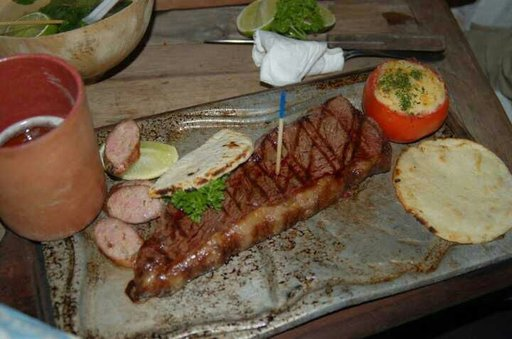

In [9]:
import random
from PIL import Image 

# Set seed
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image  path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Get image class from path name (the image class is the same of the directory where the image is stored)
image_class = random_image_path.parent.stem
print(image_class)

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width {img.width}")
img

Text(0.5, 1.0, 'Image class: steak | Image Shape: (339, 512, 3) -> height, width, color_channels')

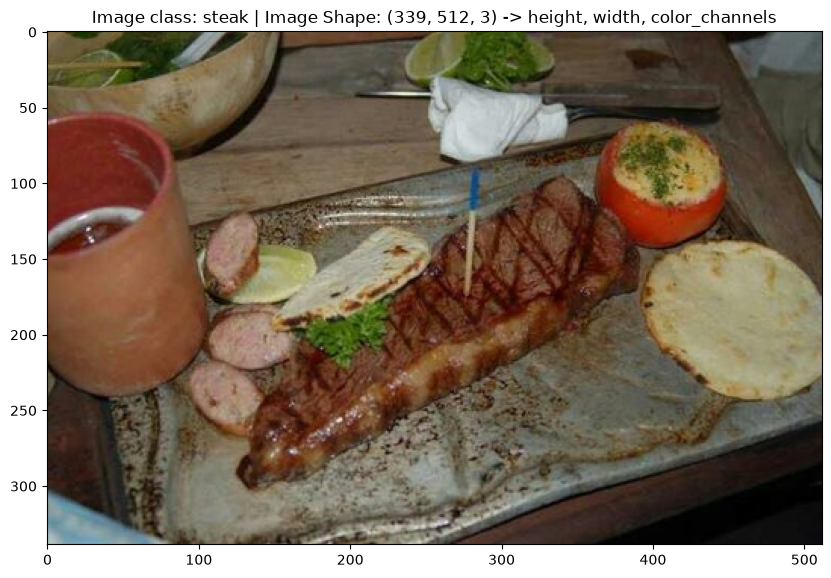

In [12]:
# Trying to visualize the image using matplotlib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize= (10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image Shape: {img_as_array.shape} -> height, width, color_channels")